Using cache found in C:\Users\chris/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-12-20 Python-3.12.10 torch-2.9.1+cpu CPU

Fusing layers... 
Model summary: 261 layers, 61497430 parameters, 0 gradients, 154.5 GFLOPs
Adding AutoShape... 
C:\Users\chris/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


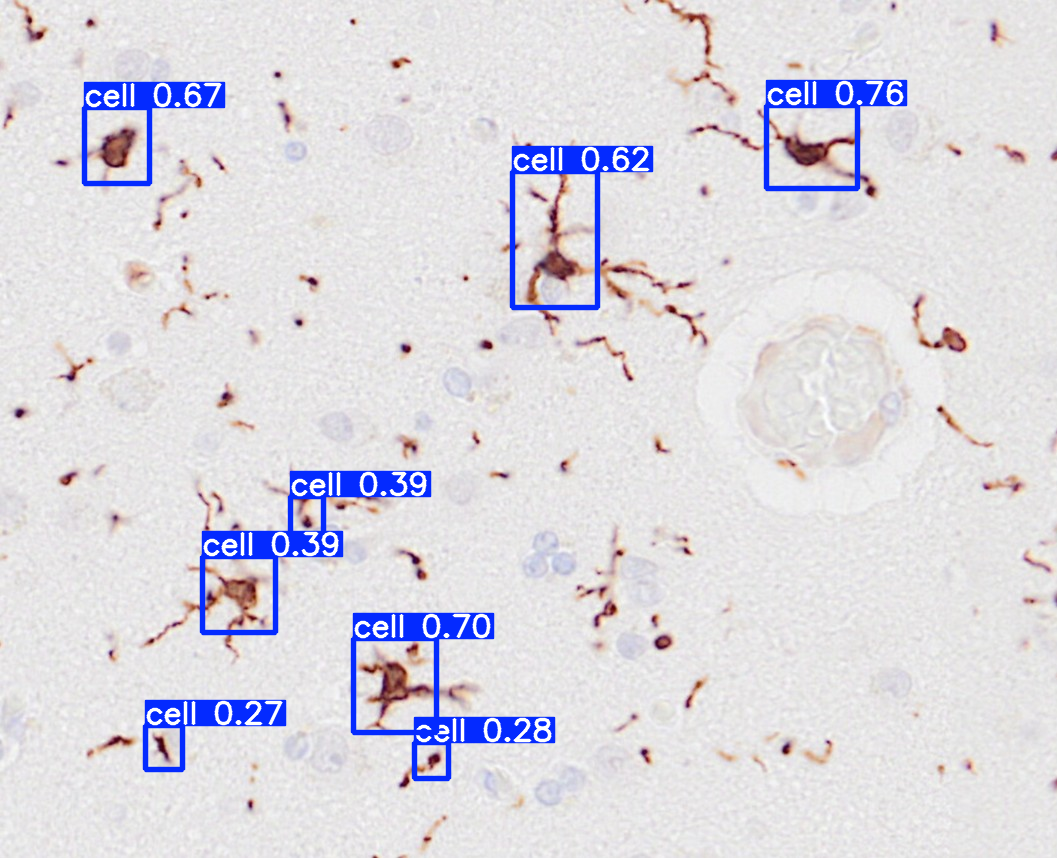

In [1]:
import torch

model = torch.hub.load(
    'ultralytics/yolov5',
    'custom',
    path='yolov3_weights.pt'   # your weights
)

# results = model("toy_dataset/microglia_big_screenshot.jpg")
# results = model("toy_dataset/nina_on_couch.jpeg")
results = model("toy_dataset/third_screenshot.jpg")
results.show()


Using cache found in C:\Users\chris/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-12-20 Python-3.12.10 torch-2.9.1+cpu CPU

Fusing layers... 
Model summary: 261 layers, 61497430 parameters, 0 gradients, 154.5 GFLOPs
Adding AutoShape... 


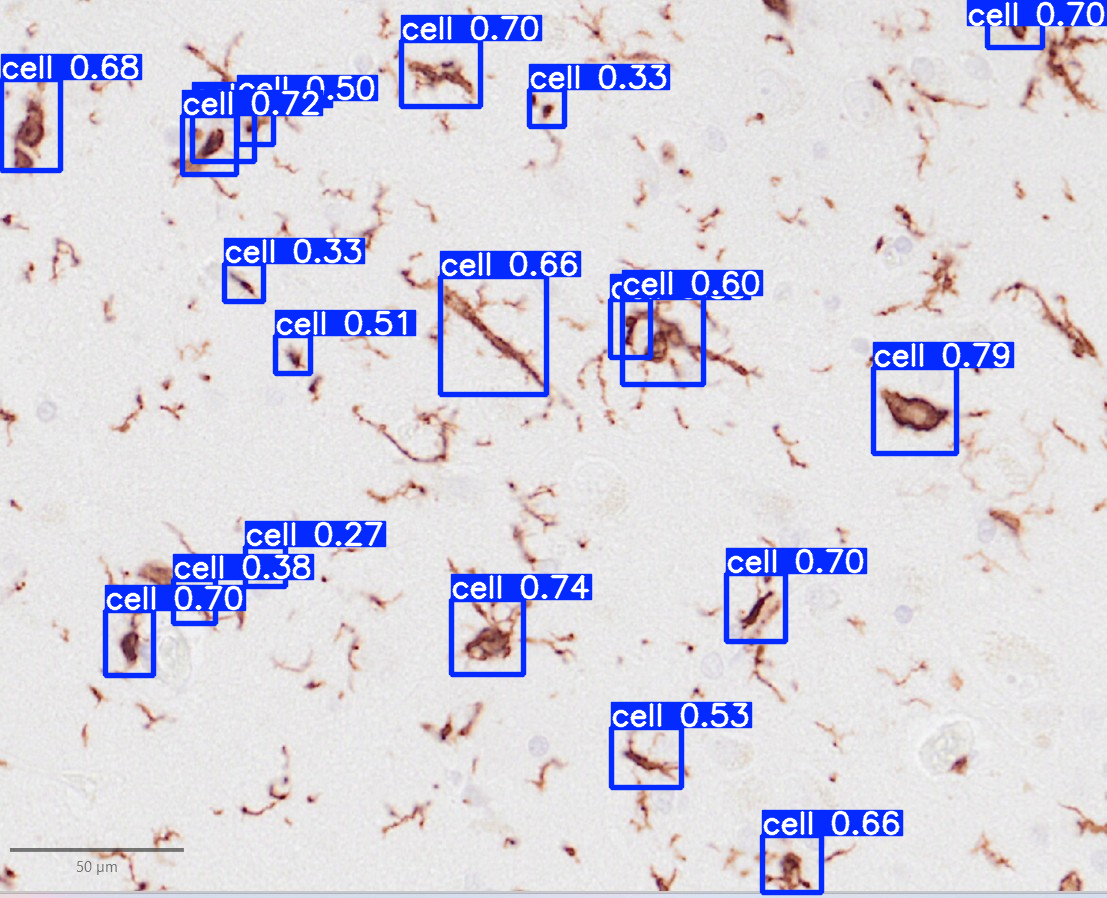

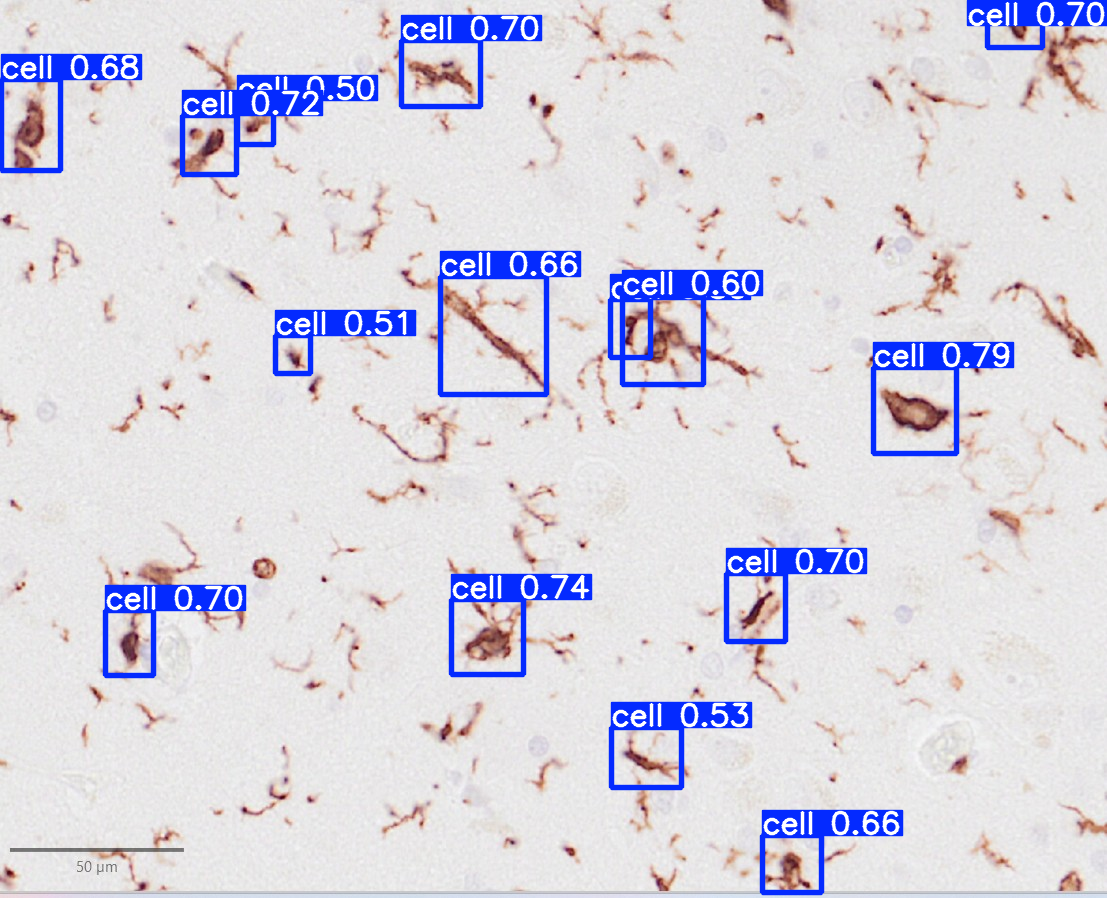

In [21]:
import torch
import cv2
import numpy as np
from segment_anything import sam_model_registry, SamPredictor

# ----------------------
# 1. Load YOLOv5 model
# ----------------------
yolo = torch.hub.load(
    'ultralytics/yolov5',
    'custom',
    path='yolov3_weights.pt'
)


image_path = "toy_dataset/microglia_big_screenshot.jpg"

# Load image for SAM
image = cv2.imread(image_path)
h, w = image.shape[:2]
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)



results = yolo(image_path)
results.show()

# YOLOv5 format: [x1, y1, x2, y2, conf, class]
detections = results.xyxy[0]

# Keep only confidence > 0.5
filtered = detections[detections[:, 4] > 0.5]

# Replace detections inside results object
results.xyxy[0] = filtered

results.show()


# annotated_img = results.render()[0]  # numpy array (BGR)

# # Save to file
# cv2.imwrite(
#     "yolo_outputs/microglia_big_screenshot_yolo.png",
#     annotated_img
# )
# Get bounding boxes (xyxy)
boxes = results.xyxy[0][:, :4].cpu().numpy()  # shape (N, 4)



# ----------------------
# 4. Load SAM
# ----------------------
sam = sam_model_registry["vit_b"](
    checkpoint="sam_files/sam_vit_b_01ec64.pth"
)
sam.to("cuda" if torch.cuda.is_available() else "cpu")

predictor = SamPredictor(sam)
predictor.set_image(image_rgb)

# ----------------------
# 5. Run SAM for each YOLO box
# ----------------------
masks = []

prompt_type = "box"

for box in boxes:
    x1, y1, x2, y2 = box.astype(int)

    if prompt_type == "point":
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2


        mask, _, _ = predictor.predict(
            point_coords=np.array([[cx, cy]]),
            point_labels=np.array([1]),  # foreground
            multimask_output=False
        )

    else:
        # by default use the entire box as the prompt
        mask, _, _ = predictor.predict(
            box=np.array([x1, y1, x2, y2]),
            multimask_output=False
        )

    masks.append(mask[0])  # (H, W)


In [22]:
import os
import imageio

os.makedirs("sam_outputs/masks", exist_ok=True)

for i, mask in enumerate(masks):
    # Convert bool → uint8 (0 or 255)
    mask_uint8 = (mask.astype("uint8") * 255)

    out_path = f"sam_outputs/masks/mask_{i:03d}.png"
    imageio.imwrite(out_path, mask_uint8)


In [23]:
import cv2
import numpy as np
import os

os.makedirs("sam_outputs/overlays", exist_ok=True)

# Copy original image so we don't overwrite it
overlay = image_rgb.copy()

for mask in masks:
    # Convert boolean mask to uint8
    mask_uint8 = (mask.astype(np.uint8) * 255)

    # Find contours
    contours, _ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw contours (green, thickness=2)
    cv2.drawContours(
        overlay,
        contours,
        contourIdx=-1,
        color=(0, 255, 0),
        thickness=2
    )

# Save result
out_path = "sam_outputs/overlays/microglia_outline_overlay.png"
cv2.imwrite(out_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))


True